In [1]:
# PyTorch and torchvision
import torch
import torchvision

# Helper libraries
import numpy as np
import matplotlib.pyplot as plt
import random

from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, random_split
import torchvision.transforms as transforms
import torch.nn as nn
import torchvision.models as models
import torch.nn.functional as F

print('=3')

=3


In [2]:
# GPU 확인
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


In [3]:
# !wget "http://vision.stanford.edu/aditya86/ImageNetDogs/images.tar" -P ~/work/data_augmentation/data
# !tar -xf ~/work/data_augmentation/data/images.tar -C ~/work/data_augmentation/data/

## **데이터 준비**

In [133]:
dataset_dir = '~/work/data_augmentation/data/Images/'

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),  # Tensor 변환
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])
full_dataset = ImageFolder(root=dataset_dir, transform=transform)

total_size = len(full_dataset)
train_size = int(0.583 * total_size) # 약 12,000개
test_size = total_size - train_size  # 약 8,580개
ds_train, ds_test = random_split(full_dataset, [train_size, test_size])

train_loader = DataLoader(ds_train, batch_size=32, shuffle=True)
test_loader = DataLoader(ds_test, batch_size=32, shuffle=False)

ds_info = {
    "num_classes" : len(full_dataset.classes),
    "class_names" : full_dataset.classes
}


print('=3')
print('total size : ',total_size, 'train size :', train_size) 

=3
total size :  20580 train size : 11998


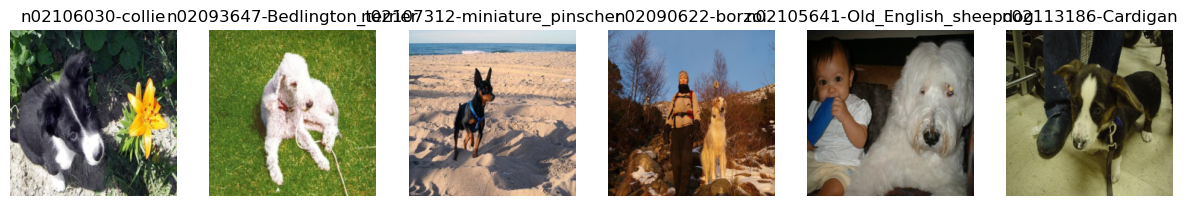

In [5]:
# DataLoader에서 일부 배치 가져오기
def show_examples(data_loader, class_names, num_images=6):
    data_iter = iter(data_loader)
    images, labels = next(data_iter)

    fig, axes = plt.subplots(1, num_images, figsize=(15,5))
    for i in range(num_images):
        image = images[i].permute(1, 2, 0).numpy() # (C, H, W) -> (H, W, C)
        image = (image * 0.5) + 0.5
        image = np.clip(image, 0, 1)

        axes[i].imshow(image)
        axes[i].axis('off')
        axes[i].set_title(class_names[labels[i].item()])

    plt.show()

# 훈련 데이터 샘플 시각화
show_examples(train_loader, ds_info['class_names'])
        

## Augmentation 적용하기  
- transforms.ColorJitter()
- transforms.RandomResizedCrop()
- transforms.RandomHorziontalFlip()
- transforms.RandomVerticalFlip()
- transforms.RandomAdjustSharpness()

In [6]:
def normalized_and_resize_img():
    return transforms.Compose([
        transforms.Resize((224, 224)), # 크기 통일
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]) # 정규화 추가
    ])

In [7]:
# transform = normalized_and_resize_img()
# full_dataset = ImageFolder(root=dataset_dir, transform=transform)

In [8]:
def augment():
    return transforms.Compose([
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.ColorJitter(brightness=0.2)
    ])

print('=3')

=3


- 코드에서 이후에 수행할 비교실험을 위해서 **with_aug** 매개변수를 통해 augmentation 의 적용 여부를 결정할 수 있도록 설정

In [9]:
# 데이터셋을 가공하는 메인함수
def apply_normalize_on_dataset(dataset, is_test=False, batch_size=16, with_aug=False):
    transform = normalized_and_resize_img()

    if not is_test and with_aug:
        dataset.dataset.transform = transforms.Compose([
            *augment().transforms,
            *transform.transforms
        ])
    else:
        dataset.dataset.transform = transform

    return DataLoader(dataset, batch_size=batch_size, shuffle=not is_test, num_workers=2, pin_memory=True)

print('=3')

=3


- Random Augmentation 직접 구현

In [10]:
def augment2():
    return transforms.Compose([
        transforms.RandomHorizontalFlip(p=0.5), # 좌우반전
        transforms.RnadomVerticalFlip(p=0.5),
        transforms.RandomRotation(degrees=(0, 90, 180, 270)), # 90도 단위 회전
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2), # 밝기 조절
        transforms.RandomResizeCrop(224, scale=(0.8, 1.0)), # 랜덤 크롭 후 리사이즈
        transforms.Lambda(lambda img: torch.clamp(img, 0, 1)) # 0-1 값으로 클리핑
        ])
print('-3')

-3


## with Augmentation vs without Augmentation

In [11]:
num_classes = len(ds_info['class_names'])
resnet50 = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
resnet50.fc = nn.Linear(resnet50.fc.in_features, num_classes)
print('-3')
print(num_classes)

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /home/jovyan/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:03<00:00, 33.2MB/s]


-3
120


In [12]:
aug_resnet50 = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
aug_resnet50.fc = nn.Linear(aug_resnet50.fc.in_features, num_classes)

print('-3')

-3


In [13]:
ds_train_no_aug = apply_normalize_on_dataset(ds_train, with_aug=False)
ds_train_aug = apply_normalize_on_dataset(ds_train, with_aug=True)
ds_test = apply_normalize_on_dataset(ds_test,is_test=True)
print('-3')

-3


In [96]:
check_img, check_label=ds_train[0]
check_img.shape, check_label

(torch.Size([3, 224, 224]), 90)

#### train

In [15]:
EPOCH =3
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(resnet50.parameters(), lr=0.001)

In [16]:
def train(model, train_loader, test_loader, epochs):
    model.to(device)
    history = {'val_accuracy':[]}

    for epoch in range(epochs):
        model.train()
        correct = 0
        total = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

                
            # 1
            outputs = model(images)

            #2
            loss= loss_fn(outputs, labels)

            # 3
            loss.backward()

            # 4
            optimizer.step()
            optimizer.zero_grad()

            # dim=1을 기준으로 가장 큰 값을 가진 인덱스를 선택 -> 예측된 클래스 번호
            _, predicted = outputs.max(1)

            # 현재 batch의 전체 샘플 수 누적
            total += labels.size(0)

            # predicted 와 truth label 을 비교해서 맞은 개수 계산
            correct += predicted.eq(labels).sum().item()

        train_acc = 100*correct / total
        print(f'Epoch [{epoch +1}/{epochs}], Accuracy : {train_acc:.2f}%')


        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, predicted = outputs.max(1)
                total += labels.size(0)
                correct += predicted.eq(labels).sum().item()

        val_acc = 100. * correct / total
        history['val_accuracy'].append(val_acc)
        print(f'Validation Accuracy: {val_acc:.2f}%')

    return history


In [17]:
history_resnet50_no_aug = train(resnet50, ds_train_no_aug, ds_test, EPOCH)

Epoch [1/3], Accuracy : 15.81%
Validation Accuracy: 40.74%
Epoch [2/3], Accuracy : 46.39%
Validation Accuracy: 61.48%
Epoch [3/3], Accuracy : 61.09%
Validation Accuracy: 71.99%


In [18]:
history_resnet50_aug = train(resnet50, ds_train_aug, ds_test, EPOCH)

Epoch [1/3], Accuracy : 69.69%
Validation Accuracy: 76.78%
Epoch [2/3], Accuracy : 75.05%
Validation Accuracy: 79.10%
Epoch [3/3], Accuracy : 77.41%
Validation Accuracy: 80.35%


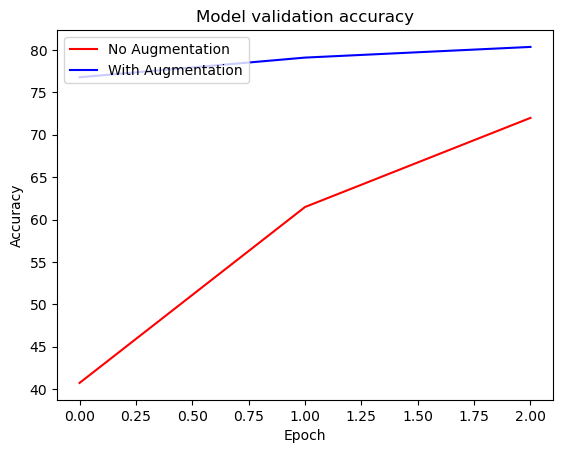

In [19]:
plt.plot(history_resnet50_no_aug['val_accuracy'], 'r', label='No Augmentation')
plt.plot(history_resnet50_aug['val_accuracy'], 'b', label='With Augmentation')
plt.title('Model validation accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='upper left')
plt.show()

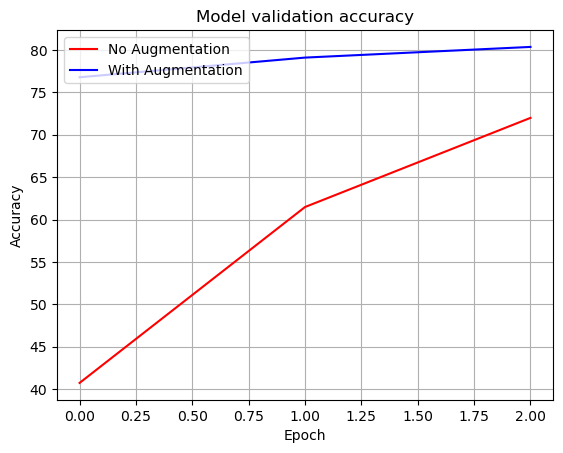

In [20]:
plt.plot(history_resnet50_no_aug['val_accuracy'], 'r', label='No Augmentation')
plt.plot(history_resnet50_aug['val_accuracy'], 'b', label='With Augmentation')
plt.title('Model validation accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='upper left')
plt.grid(True)
# plt.ylim(0.50, 0.80)    # 출력하고자 하는  Accuracy 범위를 지정해 주세요.
#plt.ylim(0.72, 0.76)  # EPOCH=20으로 진행한다면 이 범위가 적당합니다.
plt.show()

## **CutMix Augmentation**

- Mixup : 특정 비율로 픽셀별 값을 섞는 방식
- Cutout : 이미지를 잘라내는 방식

-- 이미지에서 잘라서 섞어주는 영역을 bounding box라고 부른다

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].


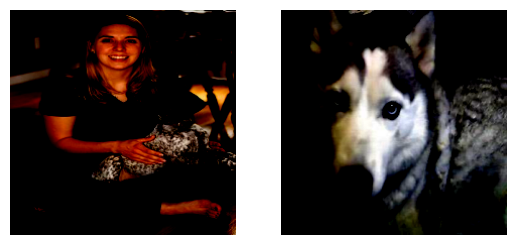

In [21]:
# dataset에서 이미지 2개를 가져온다
# DataLoader를 iterator로 변환
data_iter = iter(ds_train_no_aug)
# 한 batch를 가져옴
images, labels = next(data_iter)

# 첫 번째 배치에서 두 개의 이미지 선택
image_a = images[0].permute(1,2,0).numpy() # (C, H, W) → (H, W, C)
image_b = images[1].permute(1,2,0).numpy()
label_a = labels[0].item()
label_b = labels[1].item()

# 정규화된 텐서를 다시 [0,1] 범위로 조정
images_a = (image_a * 0.5) + 0.5
images_b = (image_b * 0.5) + 0.5

# 이미지 출력
plt.subplot(1,2,1)
plt.imshow(image_a)
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(image_b)
plt.axis('off')

plt.show()

- 사이즈에 유연하게 다루기 위해 조절

In [22]:
def get_clip_box(image_a, image_b):
    # image.shape = (channel, height, width)
    image_size_x = image_a.shape[2] # width
    image_size_y = image_a.shape[1] # height

    # get center of box
    x = torch.randint(0, image_size_x, (1,)).item()
    y = torch.randint(0, image_size_y, (1,)).item()

    # 랜덤한 크기의 사각형 영역(widith, height)을 생성하는 코드
    width = max(1, int(image_size_x * torch.sqrt(1 - torch.rand(1)).item()))
    height = max(1, int(image_size_y * torch.sqrt(1 - torch.rand(1)).item()))

    # clip box in image and get minmax bbox
    x_min = max(0, x - width //2)
    y_min = max(0, y - height //2)
    x_max = min(image_size_x, x+width //2 + 1)
    y_max = min(image_size_y, y+height //2 + 1)

    return x_min, y_min, x_max, y_max

x_min, y_min, x_max, y_max = get_clip_box(image_a, image_b)

print('x : ', x_min, x_max)
print('y : ', y_min, y_max)

x :  1 3
y :  90 224


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].


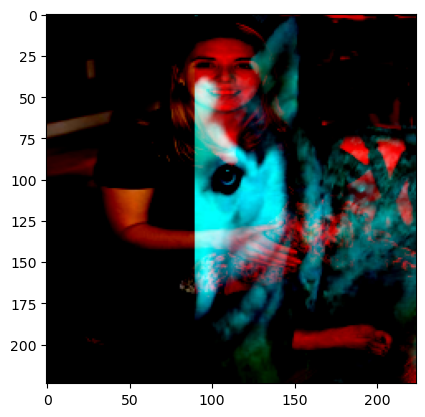

In [23]:
def mix_2_images(image_a, image_b, x_min, y_min, x_max, y_max):
    # image.shape = (C, H, W)
    image_size_x = image_a.shape[2]  # Width
    image_size_y = image_a.shape[1]  # Height

    if isinstance(image_a, np.ndarray):
        image_a = torch.from_numpy(image_a).to(device)
    if isinstance(image_b, np.ndarray):
        image_b = torch.from_numpy(image_b).to(device)

    top = image_a[:, :y_min, :]
    middle_left = image_a[:, y_min:y_max, :x_min]
    middle_center = image_b[:, y_min:y_max, x_min:x_max]
    middle_right = image_a[:, y_min:y_max, x_max:]
    bottom = image_a[:, y_max:, :]

    top = top.to(device)
    middle_left = middle_left.to(device)
    middle_center = middle_center.to(device)
    middle_right = middle_right.to(device)
    bottom = bottom.to(device)

    # 중간 부분(왼쪽, 중앙, 오른쪽) 결합
    middle = torch.cat([middle_left, middle_center, middle_right], dim=2)

    # 전체 이미지 결합 (위 + 중간 + 아래)
    mixed_img = torch.cat([top, middle, bottom], dim=1)

    return mixed_img

mixed_img = mix_2_images(image_a, image_b, x_min, y_min, x_max, y_max)

plt.imshow(mixed_img.cpu().numpy())
plt.show()

In [164]:
# mix two labels
def mix_2_labels(label_a, label_b, x_min, y_min, x_max, y_max, num_classes=120):
    image_size_x = image_a.shape[2]  # Width
    image_size_y = image_a.shape[1]  # Height

    # 바운딩 박스 비율 계산
    mixed_area = (x_max - x_min) * (y_max - y_min)
    total_area = image_size_x * image_size_y
    ratio = mixed_area / total_area

    #  # 원-핫 벡터 변환
    # if isinstance(label_a, int):
    #     label_a = F.one_hot(torch.tensor(label_a), num_classes=num_classes).float()
    # if isinstance(label_b, int):
    #     label_b = F.one_hot(torch.tensor(label_b), num_classes=num_classes).float()

    label_a = F.one_hot(torch.as_tensor(label_a).long(), num_classes).float()
    label_b = F.one_hot(torch.as_tensor(label_b).long(), num_classes).float()

    # 비율에 따라 라벨 혼합
    mixed_label = (1 - ratio) * label_a + ratio * label_b
    return mixed_label

# 예제 실행
mixed_label = mix_2_labels(label_a, label_b, x_min, y_min, x_max, y_max)
print(mixed_label)
        

tensor([0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.6012, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.3988, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 

### **mix_2_images() , mix_2_label() 활용해서 cutmix() 함수 구현**

In [165]:
def cutmix(images, labels, prob=1.0, batch_size=images.size(0), img_size=224, num_classes=120):
    mixed_imgs = []
    mixed_labels = []

    for i in range(batch_size):
        image_a = images[i]
        label_a = labels[i]

        j = torch.randint(0, batch_size, (1,)).item()  # 다른 샘플 선택
        image_b = images[j]
        label_b = labels[j]

        # 바운딩 박스 생성
        x_min, y_min, x_max, y_max = get_clip_box(image_a, image_b)

        # 이미지 섞기
        mixed_imgs.append(mix_2_images(image_a, image_b, x_min, y_min, x_max, y_max))
        mixed_labels.append(mix_2_labels(label_a, label_b, x_min, y_min, x_max, y_max, num_classes))

    # 텐서 변환
    mixed_imgs = torch.stack(mixed_imgs).reshape(batch_size, 3, img_size, img_size)
    mixed_labels = torch.stack(mixed_labels).reshape(batch_size, num_classes)

    return mixed_imgs, mixed_labels

print("=3")

=3


## **Mixup Augmentation**

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.98838097].


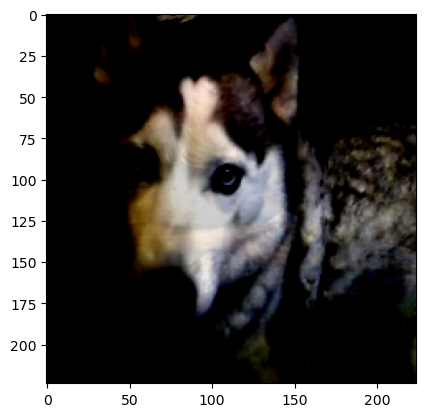

tensor([0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0988, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.9012, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 

In [108]:
# function for mixup
def mixup_2_images(image_a, image_b, label_a, label_b, num_classes=120):
    ratio = torch.rand(1).item()  # 0~1 사이의 랜덤 값

    # 라벨 원핫 인코딩
    # # x 가 int 타입인지 확인
    # if isinstance(label_a, int):
    #     label_a = F.one_hot(torch.tensor(label_a), num_classes=num_classes).float()
    # if isinstance(label_b, int):
    #     label_b = F.one_hot(torch.tensor(label_b), num_classes=num_classes).float()

    # # 🔥 무조건 one-hot 변환
    label_a = F.one_hot(torch.as_tensor(label_a).long(), num_classes).float()
    label_b = F.one_hot(torch.as_tensor(label_b).long(), num_classes).float()

    # 이미지와 라벨 혼합
    mixed_image = (1 - ratio) * image_a + ratio * image_b
    mixed_label = (1 - ratio) * label_a + ratio * label_b

    return mixed_image, mixed_label

# 예제 실행
mixed_img, mixed_label = mixup_2_images(image_a, image_b, label_a, label_b)

plt.imshow(mixed_img)
plt.show()

print(mixed_label)

In [136]:
def mixup(images, labels, batch_size=images.size(0), img_size=224, num_classes=120):
    mixed_imgs = []
    mixed_labels = []

    for i in range(batch_size):
        image_a = images[i]
        label_a = labels[i]

        # 랜덤하게 다른 이미지 선택
        j = torch.randint(0, batch_size, (1,)).item()
        image_b = images[j]
        label_b = labels[j]

        # Mixup 적용
        mixed_img, mixed_label = mixup_2_images(image_a, image_b, label_a, label_b, num_classes)

        mixed_imgs.append(mixed_img)
        mixed_labels.append(mixed_label)

    # 배치 차원 추가
    mixed_imgs = torch.stack(mixed_imgs).view(batch_size, 3, img_size, img_size)  # (B, C, H, W)
    mixed_labels = torch.stack(mixed_labels).view(batch_size, num_classes)  # (B, num_classes)

    return mixed_imgs, mixed_labels

print('=3')

=3


## Augmentation 을 적용한 데이터셋 만들기

In [137]:
# 이미지 정규화 및 크기 조정
def get_transform(mode='no_aug'):
    if mode == 'basic_aug':
        return transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.ColorJitter(brightness=0.2),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.5]*3, std=[0.5]*3),
        ])

    else: # no_aug
        return transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.5]*3, std=[0.5]*3),
        ])

# 데이터셋 적용
def build_dataloaders(dataset_dir, batch_size=32, aug_mode='no_aug'):
    base_dataset = ImageFolder(dataset_dir, transform=None)

    train_size = int(0.8*len(base_dataset))
    test_size = len(base_dataset) - train_size

    train_indices, test_indices = random_split(
        range(len(base_dataset)),
        [train_size, test_size]
    )

    # 전체 데이터셋에서 일부 인덱스만 골라서 새로운 데이터셋 만드는 코드
    train_dataset = torch.utils.data.Subset(
        ImageFolder(dataset_dir, transform=get_transform(aug_mode)),
        train_indices.indices
    )

    test_dataset = torch.utils.data.Subset(
        ImageFolder(dataset_dir, transform=get_transform('no_aug')),
        test_indices.indices
    )

    # num_works : 데이터를 몇 개의 프로세스로 병렬 로딩할지
    # pin_memory : GPU 로 데이터 더 빠르게 보내기 위한 옵션
    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=0,
        pin_memory=False
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
        pin_memory=False
    )

    return train_loader, test_loader, base_dataset

print('-3')


-3


## 모델 만들기

In [138]:
train_loader, test_loader, base_dataset = build_dataloaders(dataset_dir)

In [142]:
data_iter = iter(train_loader)
images, labels = next(data_iter)

print(images.shape)
print(labels)

print(len(train_loader.dataset))  # 전체 이미지 개수
print(len(train_loader))   

torch.Size([32, 3, 224, 224])
tensor([ 58,   8,  38,  81,  18,  87,  45,  40,  87, 102,  20,   9,  76,  83,
         76, 117,  97, 111,   9,  90,  76,  65,  48,  14,  70,  72,  66,  14,
         95, 112,  90,   5])
16464
515


In [156]:
test_img,test_label=mixup(images,labels.tolist())
print(test_img.shape,test_label.shape)

test_img,test_label=cutmix(images,labels.tolist())
print(test_img.shape,test_label.shape)

torch.Size([32, 3, 224, 224]) torch.Size([32, 120])
torch.Size([32, 3, 224, 224]) torch.Size([32, 120])


In [148]:
ds_train_no_aug = apply_normalize_on_dataset(ds_train, with_aug=False)
ds_train_aug = apply_normalize_on_dataset(ds_train, with_aug=True)
ds_test = apply_normalize_on_dataset(ds_test,is_test=True)

In [158]:
def train_aug(model, train_loader, test_loader, epochs, use_mixup=False, use_cutmix=False):
    model.to(device)
    history = {'val_accuracy':[]}

    # loss function 설정
    if use_mixup or use_cutmix:
        loss_fn=mixup_loss
    else:
        loss_fn = nn.CrossEntropyLoss()
        
    for epoch in range(epochs):
        model.train()
        correct = 0
        total = 0

        for images, labels in train_loader:
            if use_mixup:
                images, labels = mixup(images, labels, batch_size=images.size(0))
            elif use_cutmix:
                images, labels = cutmix(images, labels, batch_size=images.size(0))
            
            images, labels = images.to(device), labels.to(device)

                
            # 1
            outputs = model(images)

            #2
            loss= loss_fn(outputs, labels)

            # 3
            loss.backward()

            # 4
            optimizer.step()
            optimizer.zero_grad()

            # dim=1을 기준으로 가장 큰 값을 가진 인덱스를 선택 -> 예측된 클래스 번호
            _, predicted = outputs.max(1)

            # 현재 batch의 전체 샘플 수 누적
            total += labels.size(0)


            if use_mixup or use_cutmix:
                _, target = labels.max(1)
            else:
                target = labels
            # predicted 와 truth label 을 비교해서 맞은 개수 계산
            correct += predicted.eq(target).sum().item()

        train_acc = 100*correct / total
        print(f'Epoch [{epoch +1}/{epochs}], Accuracy : {train_acc:.2f}%')


        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, predicted = outputs.max(1)
                total += labels.size(0)

                # if use_mixup or use_cutmix:
                #     _, taget = labels.max(1)
                # else:
                #     target = labels
                correct += predicted.eq(labels).sum().item()

        val_acc = 100. * correct / total
        history['val_accuracy'].append(val_acc)
        print(f'Validation Accuracy: {val_acc:.2f}%')

    return history


In [159]:
for images, labels in train_loader:
    print(images.shape)
    print(labels.shape)
    break

torch.Size([32, 3, 224, 224])
torch.Size([32])


In [160]:
print("train_loader:", type(ds_train_no_aug))
print("test_loader:", type(ds_test))

train_loader: <class 'torch.utils.data.dataloader.DataLoader'>
test_loader: <class 'torch.utils.data.dataloader.DataLoader'>


In [174]:
EPOCH =10
optimizer = torch.optim.Adam(resnet50.parameters(), lr=0.001)
def mixup_loss(outputs, labels):
    return -(labels * torch.log_softmax(outputs, dim=1)).sum(dim=1).mean()

#### **Soft Cross Entropy Loss function**

- mixup 과 cutmix는 두 개 이상의 클래스 정보를 확률적으로 혼합한 soft labe을 생성하므로, 단일 클래스 인덱스를 가정하는 CrossEntropyLoss 대신 확률 분포를 반영할 수있는 softt cross entropy 를 사용

### **Baseline**

In [170]:
history_resnet50_baseline = train_aug(resnet50, ds_train_no_aug, ds_test, EPOCH,use_mixup=False, use_cutmix=False)

Epoch [1/10], Accuracy : 0.96%
Validation Accuracy: 0.96%
Epoch [2/10], Accuracy : 1.21%
Validation Accuracy: 0.96%
Epoch [3/10], Accuracy : 1.46%
Validation Accuracy: 1.91%
Epoch [4/10], Accuracy : 2.37%
Validation Accuracy: 2.31%
Epoch [5/10], Accuracy : 2.80%
Validation Accuracy: 2.96%
Epoch [6/10], Accuracy : 3.73%
Validation Accuracy: 4.05%
Epoch [7/10], Accuracy : 5.12%
Validation Accuracy: 5.49%
Epoch [8/10], Accuracy : 7.18%
Validation Accuracy: 6.39%
Epoch [9/10], Accuracy : 8.82%
Validation Accuracy: 8.17%
Epoch [10/10], Accuracy : 10.57%
Validation Accuracy: 9.78%


### **Basic Augmentation**

In [171]:
history_resnet50_basic_aug = train_aug(resnet50, ds_train_aug, ds_test, EPOCH,use_mixup=False, use_cutmix=False)

Epoch [1/10], Accuracy : 12.30%
Validation Accuracy: 8.69%
Epoch [2/10], Accuracy : 15.16%
Validation Accuracy: 12.03%
Epoch [3/10], Accuracy : 18.11%
Validation Accuracy: 14.27%
Epoch [4/10], Accuracy : 21.97%
Validation Accuracy: 15.75%
Epoch [5/10], Accuracy : 25.98%
Validation Accuracy: 17.42%
Epoch [6/10], Accuracy : 30.96%
Validation Accuracy: 16.49%
Epoch [7/10], Accuracy : 35.38%
Validation Accuracy: 17.05%
Epoch [8/10], Accuracy : 41.89%
Validation Accuracy: 18.10%
Epoch [9/10], Accuracy : 48.51%
Validation Accuracy: 17.70%
Epoch [10/10], Accuracy : 56.69%
Validation Accuracy: 14.66%


### **Basic Augmentation + Mixup**

In [172]:
# soft cross entropy
history_resnet50_mixup = train_aug(resnet50, ds_train_aug, ds_test, EPOCH,use_mixup=True, use_cutmix=False)

Epoch [1/10], Accuracy : 39.46%
Validation Accuracy: 16.43%
Epoch [2/10], Accuracy : 41.78%
Validation Accuracy: 15.85%
Epoch [3/10], Accuracy : 43.77%
Validation Accuracy: 15.45%
Epoch [4/10], Accuracy : 46.67%
Validation Accuracy: 17.11%
Epoch [5/10], Accuracy : 48.24%
Validation Accuracy: 17.75%
Epoch [6/10], Accuracy : 50.39%
Validation Accuracy: 17.28%
Epoch [7/10], Accuracy : 52.76%
Validation Accuracy: 15.44%
Epoch [8/10], Accuracy : 55.43%
Validation Accuracy: 17.09%
Epoch [9/10], Accuracy : 57.20%
Validation Accuracy: 16.71%
Epoch [10/10], Accuracy : 59.65%
Validation Accuracy: 17.98%


### **Basic Augmentation + CutMix**

In [173]:
history_resnet50_cutmix = train_aug(resnet50, ds_train_aug, ds_test, EPOCH,use_mixup=False, use_cutmix=True)

Epoch [1/10], Accuracy : 0.93%
Validation Accuracy: 0.99%
Epoch [2/10], Accuracy : 0.80%
Validation Accuracy: 0.71%
Epoch [3/10], Accuracy : 0.95%
Validation Accuracy: 0.90%
Epoch [4/10], Accuracy : 0.78%
Validation Accuracy: 0.64%
Epoch [5/10], Accuracy : 0.83%
Validation Accuracy: 0.50%
Epoch [6/10], Accuracy : 0.78%
Validation Accuracy: 0.58%
Epoch [7/10], Accuracy : 0.83%
Validation Accuracy: 0.56%
Epoch [8/10], Accuracy : 0.76%
Validation Accuracy: 0.71%
Epoch [9/10], Accuracy : 0.61%
Validation Accuracy: 0.56%
Epoch [10/10], Accuracy : 0.66%
Validation Accuracy: 0.54%


### 나의 결과 문제점

 - basic augmentation : 성능 향상에는 한계가 있다, overfitting 이 보임
 - mixup : overfitting은 basic augmentation 보다 좋아졌고, 성능 향상도 있었다. 수렴 속도가 basline , basic augmentation 보다 느리게 수렴하는 것 같다
 - cutmix : 이유는 모르겠지만, underfitting이 모습을 보인다. epoch가 진행될 수록 accuracy 가 낮아진다

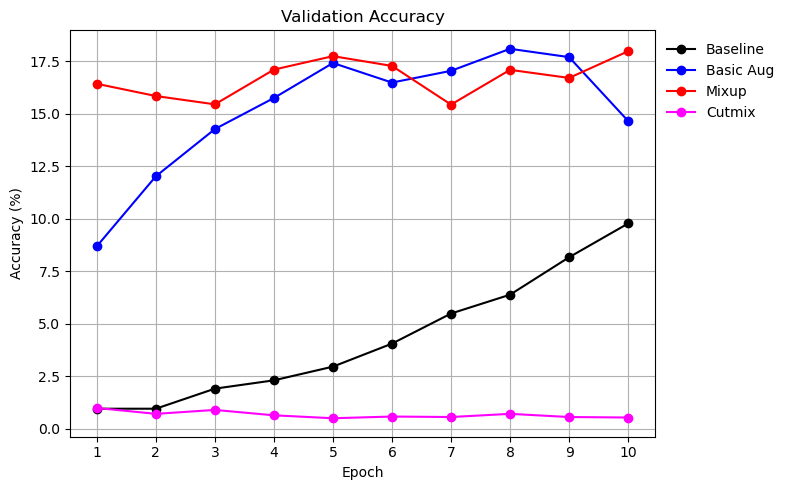

In [186]:
import matplotlib.pyplot as plt

# history들 모으기
histories = {
    "baseline": history_resnet50_baseline,
    "basic_aug": history_resnet50_basic_aug,
    "mixup": history_resnet50_mixup,
    "cutmix": history_resnet50_cutmix
}

x = range(1, EPOCH + 1)
plt.figure(figsize=(8,5))

# 🔹 1. Validation Accuracy plot (전체 비교)
plt.subplot(1,1,1)

labels = ['Baseline', 'Basic Aug', 'Mixup', 'Cutmix']
colors = ['k', 'blue', 'red', 'magenta']

for (name, history), label, color in zip(histories.items(), labels, colors):
    plt.plot(x,
        history['val_accuracy'],
        linestyle='-',
        marker='o',
        label=label,
        color=color
    )

plt.title("Validation Accuracy")
plt.ylabel("Accuracy (%)")
plt.legend(loc='upper left', bbox_to_anchor=(1,1),frameon=False)
plt.grid()
plt.xlabel("Epoch")
plt.xticks(range(1, EPOCH+ 1))

plt.tight_layout()
plt.show()

## 회고

- 데이터의 수를 늘리기위한 방법으로 augmentation 방법들을 배웠다. 다양한 정보를 추출하기 위해서 이미지를 특정한 비율로 섞는 Mixup, 여러 이미지를 잘라서 섞는 Cutmix와 같은 기법들이 존재한다.
- 그렇지만 Mixup, Cutmix가 비슷하게 좋은 결과를 낼 것이라고 생각했다
- 물론 val accuracy자체는 mixup이 좋게 나왔지만,여전히 overfitting의 문제가 있었다.
- Basic Augmentation은 10 epoch 이후 점차 accuracy가 낮아지는 것으로 보이고, Mixup은 계속 높아질 것처럼 보여 epoch을 늘리면 mixup에서 가장 좋은 성능을 보일 것 같다
- 반대로 baseline model에서도 느리지만 계속 accuracy가 높아지는 모습을 보인다. 이 문제는 어쩌면 augmentation을 하지 않아도 좋은 성능을 낼 수 있는 문제가 아닐까 생각을 해보았다.
- mixup에서는 성능이 나오는데, cutmix에서 성능이 떨어지는 경우 : cutmix가 이미지 구조를 깨뜨리기 때문에 특정 상황에서 성능이 떨어질 수 있다고는 하는데 현재 데이터에 같은 문제가 발생한 건지는 아직 잘 모르겠다